## Simple Exponential Smoothing (SES) 

       Symbol Series         Date  PrevClose  OpenPrice  HighPrice  LowPrice  \
0  TATACOFFEE     EQ  05-Jan-2022     217.80     218.50      218.7    214.30   
1  TATACOFFEE     EQ  04-Jan-2022     214.05     214.90      220.8    212.45   
2  TATACOFFEE     EQ  03-Jan-2022     213.15     213.95      216.9    212.30   
3  TATACOFFEE     EQ  31-Dec-2021     208.50     208.90      216.2    208.40   
4  TATACOFFEE     EQ  30-Dec-2021     211.35     211.45      211.5    207.90   

   LastPrice  ClosePrice  AveragePrice TotalTradedQuantity        Turnover₹  \
0     214.65      214.85        215.72           13,50,483  29,13,25,687.40   
1     217.40      217.80        217.41           34,77,443  75,60,37,979.15   
2     214.30      214.05        214.76           15,25,259  32,75,66,528.25   
3     213.70      213.15        213.37           30,45,699  64,98,54,073.20   
4     208.80      208.50        209.36            9,77,484  20,46,47,553.50   

  No.ofTrades  
0      12,079  
1      28,87

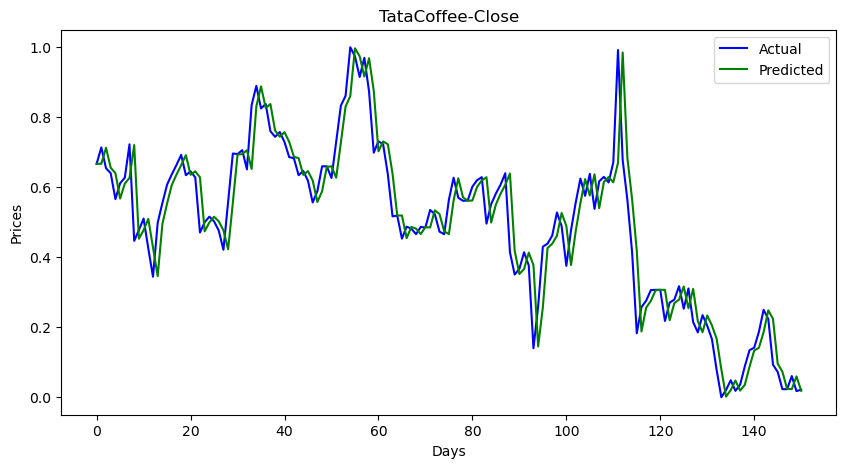

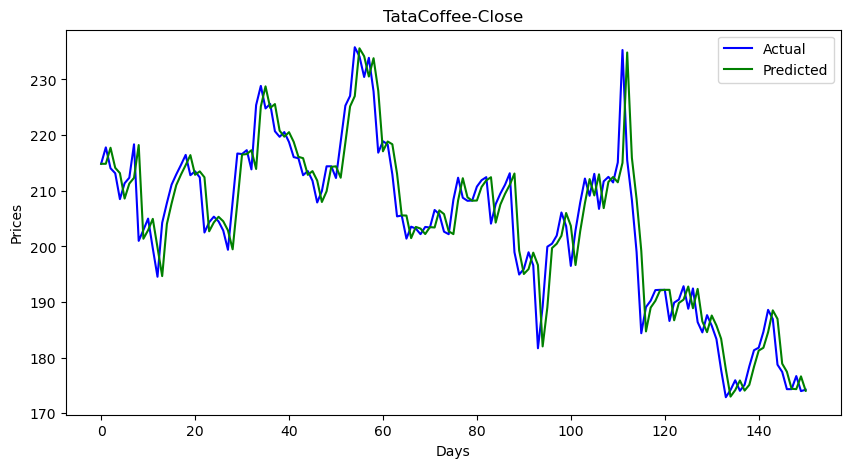

RMSE-Testset: 5.2695161753376345
maPe-Testset: 0.01833596585617771
Future Forecast (Scaled):
151    0.021395
152    0.021395
dtype: float64
Forecast in Original Scale:
    Closefore
0  174.245771
1  174.245771


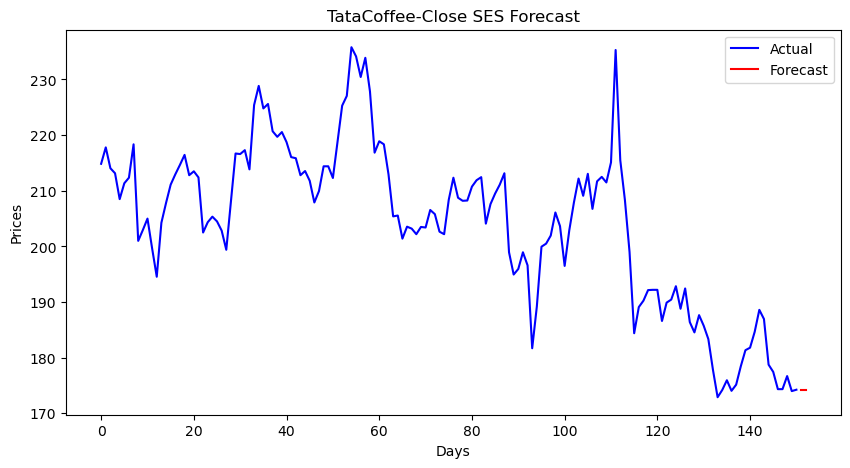

In [2]:
import pandas as pd
from nselib import capital_market as cm

# Define dates as strings in DD-MM-YYYY format
start_date = '01-06-2021'
end_date = '05-01-2022'

# Use the correct function: price_volume_data
stk_data = cm.price_volume_data(symbol='TATACOFFEE', from_date=start_date, to_date=end_date)

print(stk_data.head())

# Select required columns
stk_data = stk_data[["OpenPrice", "HighPrice", "LowPrice", "ClosePrice"]]

# Select target column
column = "ClosePrice"

# Scale only ClosePrice
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1 = Ms.fit_transform(stk_data[[column]])

print("Len:", data1.shape)

# Convert scaled array into DataFrame
data1 = pd.DataFrame(data1, columns=[column])

# Apply Simple Exponential Smoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
model = SimpleExpSmoothing(data1[column])
model_fit = model.fit(optimized=True)

# Make prediction for the full available series
y_pred = model_fit.fittedvalues

# Convert prediction to DataFrame
from stockFunctions import conversionSingle
pTestNormTable = conversionSingle(y_pred.values, [column])

# Evaluate on normalized data
from stockFunctions import rmsemape
rmsemape(data1, pTestNormTable)

# Plot normalized actual vs predicted
from stockFunctions import graph
graph(data1, pTestNormTable, "Actual", "Predicted", "TataCoffee-Close", "Days", "Prices")

# Convert actual scaled data back to original scale
aTestNormTable = conversionSingle(data1.values, [column])
actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, [column])

# Convert predicted scaled data back to original scale
predicted_stock_price_test_ori = Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP = conversionSingle(predicted_stock_price_test_ori, [column])

# Plot original scale actual vs predicted
graph(actual_stock_price_test_oriA, predicted_stock_price_test_oriP,
      "Actual", "Predicted", "TataCoffee-Close", "Days", "Prices")

# Evaluate on original scale
rmsemape(actual_stock_price_test_oriA, predicted_stock_price_test_oriP)

# Forecast next 2 future values
forecast = model_fit.forecast(2)
print("Future Forecast (Scaled):")
print(forecast)

# Convert forecast to DataFrame
fTestNormTable = conversionSingle(forecast.values, ["Closefore"])

# Since scaler was fit on ClosePrice only, rename for inverse transform compatibility
fTestNormTable.columns = [column]

# Convert forecast back to original scale
forecast_stock_price_test_ori = Ms.inverse_transform(fTestNormTable)

# Convert back to DataFrame with desired forecast column name
forecast_stock_price_test_oriF = conversionSingle(forecast_stock_price_test_ori, ["Closefore"])

# Save forecast to CSV
forecast_stock_price_test_oriF.to_csv("Closetses.csv", index=False)

print("Forecast in Original Scale:")
print(forecast_stock_price_test_oriF)

# Plot actual and future forecast
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(actual_stock_price_test_oriA, color='blue', label="Actual")
plt.plot(range(len(actual_stock_price_test_oriA), len(actual_stock_price_test_oriA) + len(forecast_stock_price_test_oriF)),
         forecast_stock_price_test_oriF, color='red', label="Forecast")
plt.title("TataCoffee-Close SES Forecast")
plt.xlabel("Days")
plt.ylabel("Prices")
plt.legend()
plt.show()
